In [2]:
import numpyro
numpyro.set_host_device_count(4)

In [3]:
import numpy as np
import pandas as pd
import hssm
import ssms.basic_simulators
import pytensor
import os
import matplotlib.pyplot as plt
import glob

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [ ]:
pytensor.config.floatX = "float32"
hssm.set_floatX("float32")

In [4]:
df = pd.read_csv('../data/allT.csv')

In [5]:
T1 = pd.read_parquet("../data/after_T1.parquet")
T3 = pd.read_parquet("../data/after_T3.parquet")

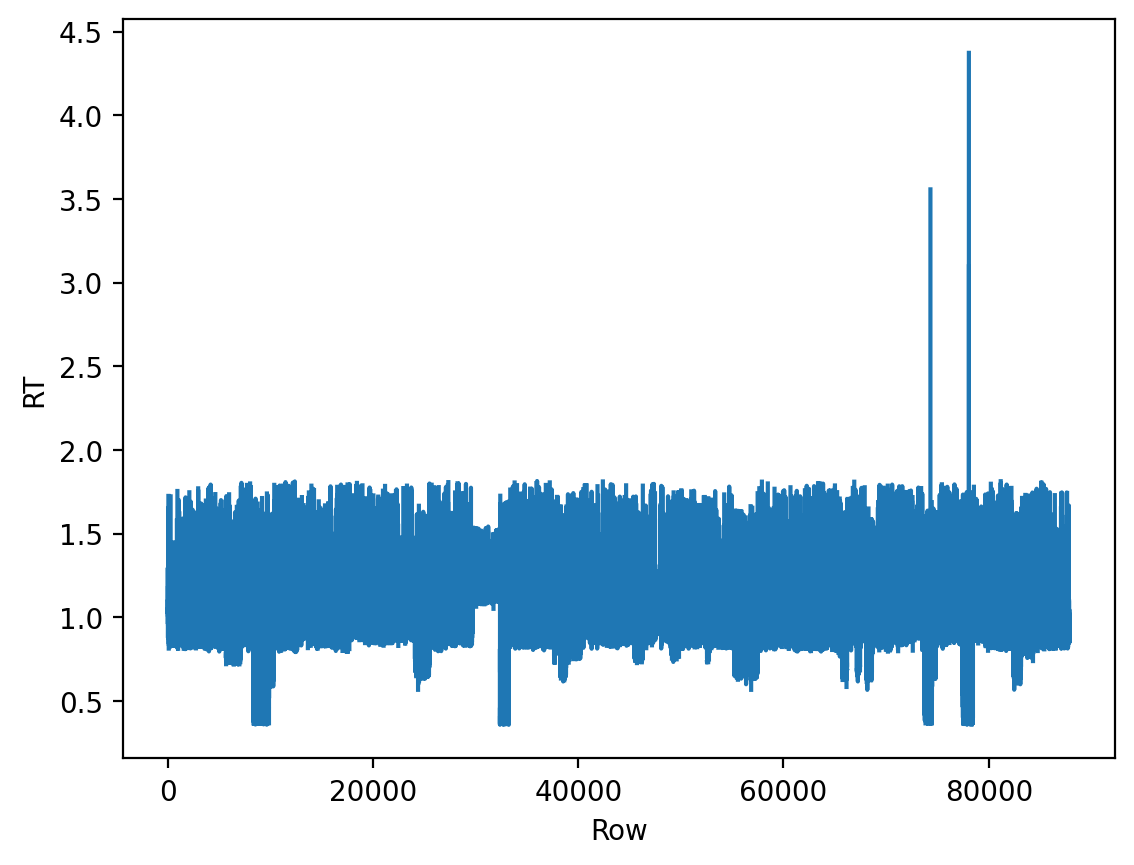

In [6]:
plt.plot(T1["ReactionTime"])
plt.xlabel("Row")
plt.ylabel("RT")
plt.show()

In [29]:
df[(df["ReactionTime"] < 0.36) & (df["ReactionTime"] > 0)]

,Trial,RatID,Date,StimOn,Correct,InstruResp,ReactionTime,PeakVel,PeakVelTime,VelTime_1,...,VelTrace_354,VelTrace_355,VelTrace_356,VelTrace_357,VelTrace_358,VelTrace_359,VelTrace_360,VelTrace_361,VelTrace_362,CR_Label
152670,105,230,31224,651.857061,3,652.216186,0.359125,NaN,NaN,0.002437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152991,26,230,41224,134.969790,3,135.329665,0.359875,NaN,NaN,0.003750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153843,78,230,51224,285.617398,1,285.976117,0.358719,NaN,NaN,0.001094,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
157723,358,230,131224,1108.363778,1,1108.723591,0.359813,NaN,NaN,0.004719,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
157758,393,230,131224,1206.141528,1,1206.501309,0.359781,NaN,NaN,0.001969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
157822,457,230,131224,1389.987966,1,1390.346403,0.358437,NaN,NaN,0.000531,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
159520,355,230,181224,1099.572066,3,1099.930847,0.358781,NaN,NaN,0.001688,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
161071,106,230,261224,337.090784,1,337.450659,0.359875,NaN,NaN,0.004125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
161792,427,230,271224,1385.454538,1,1385.811288,0.356750,NaN,NaN,0.004312,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
163003,38,232,41224,186.034718,3,186.394687,0.359969,NaN,NaN,0.004407,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
tmp_df = T1[["RatID", "Trial", "Date", "Correct", "ReactionTime"]].copy()

tmp_df = tmp_df.rename(columns={
    "RatID": "subj_idx",
    "ReactionTime": "rt"
})

tmp_df["response"] = np.where(
    tmp_df["Correct"].isin([0, 1]),
    1,     # go stimulus
    -1     # no-go stimulus
)

tmp_df["rt"] = tmp_df["rt"].fillna(-999)

tmp_df["deadline"] = 1.75

tmp_df = tmp_df[["subj_idx", "rt", "response", "deadline", "Trial", "Date", "Correct"]]
T1model_df = tmp_df[["subj_idx", "rt", "response", "deadline"]].copy()

In [ ]:
T1model_df = T1model_df.copy()

T1model_df["rt"] = T1model_df["rt"].astype("float32")
T1model_df["deadline"] = T1model_df["deadline"].astype("float32")
T1model_df["response"] = T1model_df["response"].astype("int32")
T1model_df["subj_idx"] = T1model_df["subj_idx"].astype("int32")

In [ ]:
tmp_df = T3[["RatID", "Trial", "Date", "Correct", "ReactionTime"]].copy()

tmp_df = tmp_df.rename(columns={
    "RatID": "subj_idx",
    "ReactionTime": "rt"
})

tmp_df["response"] = np.where(
    tmp_df["Correct"].isin([0, 1]),
    1,     # go stimulus
    -1     # no-go stimulus
)

tmp_df["rt"] = tmp_df["rt"].fillna(-999)

tmp_df["deadline"] = 1.75

tmp_df = tmp_df[["subj_idx", "rt", "response", "deadline", "Trial", "Date", "Correct"]]
T3model_df = tmp_df[["subj_idx", "rt", "response", "deadline"]].copy()

In [ ]:
T3model_df = T3model_df.copy()

T3model_df["rt"] = T3model_df["rt"].astype("float32")
T3model_df["deadline"] = T3model_df["deadline"].astype("float32")
T3model_df["response"] = T3model_df["response"].astype("int32")
T3model_df["subj_idx"] = T3model_df["subj_idx"].astype("int32")

In [ ]:
m = hssm.HSSM(
    data=T1model_df,
    model="ddm",
    missing_data=True,
    deadline="deadline",
    loglik_kind="approx_differentiable",
    loglik_missing_data="onnx/ddm_opn.onnx"
)

In [ ]:
m.graph()

In [ ]:
idata = m.sample( sampler="numpyro", chains=4, cores=4, draws=100, tune=100, progressbar=True )

In [ ]:
m.summary()

In [ ]:
m.plot_trace()

In [ ]:
m3 = hssm.HSSM(
    data=T3model_df,
    model="ddm",
    missing_data=True,
    deadline="deadline",
    loglik_kind="approx_differentiable",
    loglik_missing_data="ddm_opn.onnx"
)

In [ ]:
idata = m3.sample( sampler="numpyro", chains=4, cores=4, draws=500, tune=500, progressbar=True )

In [ ]:
m3.graph()

In [ ]:
m3.summary()

In [ ]:
m3.plot_trace()

In [ ]:
import onnx

model = onnx.load("ddm_opn.onnx")

for inp in model.graph.input:
    print(inp.name, inp.type.tensor_type.shape)